### Exploratory Data Analysis

#### Importing Packages and Loading Data

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [5]:
# Paths
project_root = Path.cwd().parent
processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "reports" / "figures"

In [6]:
# Loading the Dataset
df = pd.read_parquet(processed_dir/"london_crime.parquet")

df

,crime_id,month,reported_by,longitude,latitude,location,lsoa_code,lsoa_name,crime_type,last_outcome_category,source_file
0,e7b720d0e1302d2d06db7b28b29132eb194864d44d7921...,2024-01,City of London Police,-0.106220,51.518275,On or near B500,E01000916,Camden 027B,Theft from the person,Investigation complete; no suspect identified,2024-01-city-of-london-street.csv
1,e60a5ac62a80e866453254474137c3206417422c62f0c0...,2024-01,City of London Police,-0.107682,51.517786,On or near B521,E01000917,Camden 027C,Other theft,Investigation complete; no suspect identified,2024-01-city-of-london-street.csv
2,986f618142ec52b7f254e4b0549da2f17ceeb0e130db6c...,2024-01,City of London Police,-0.111596,51.518281,On or near Chancery Lane,E01000914,Camden 028B,Other theft,Investigation complete; no suspect identified,2024-01-city-of-london-street.csv
3,05dc27a88748356f6d59b0bd1389710ebfb42b37e565af...,2024-01,City of London Police,-0.111596,51.518281,On or near Chancery Lane,E01000914,Camden 028B,Theft from the person,Status update unavailable,2024-01-city-of-london-street.csv
4,373d78e2ccec5d05a547cd4bee19045a9e050042a0e6e7...,2024-01,City of London Police,-0.112096,51.515942,On or near Nightclub,E01000914,Camden 028B,Theft from the person,Investigation complete; no suspect identified,2024-01-city-of-london-street.csv
...,...,...,...,...,...,...,...,...,...,...,...
2287668,8cfa73aac9ffd2e8f0d597b4b1e529bacc2cc3e82d509a...,2025-12,Metropolitan Police Service,-0.137230,51.486309,On or near Parking Area,E01035722,Westminster 024G,Violence and sexual offences,Under investigation,2025-12-metropolitan-street.csv
2287669,4822666edb3d22a5680ec316ce7c5cef0d861d659b3fa2...,2025-12,Metropolitan Police Service,-0.135320,51.487600,On or near St George'S Square,E01035722,Westminster 024G,Violence and sexual offences,Unable to prosecute suspect,2025-12-metropolitan-street.csv
2287670,e86e036bb9da06e7cdfa8ffc5caa4d3e5bb8f68d21a24a...,2025-12,Metropolitan Police Service,-0.133538,51.487500,On or near Aylesford Street,E01035722,Westminster 024G,Violence and sexual offences,Action to be taken by another organisation,2025-12-metropolitan-street.csv
2287671,f20a67354e3c9415f5e0281f9e084f1dbae4e858ad0b62...,2025-12,Metropolitan Police Service,-0.133538,51.487500,On or near Aylesford Street,E01035722,Westminster 024G,Violence and sexual offences,Unable to prosecute suspect,2025-12-metropolitan-street.csv


#### Month

In [7]:
# Total crime changes month to month
monthly = df["month"].value_counts().sort_index()
monthly

month
2024-01     90597
2024-02     90333
2024-03     92117
2024-04     90802
2024-05     97753
2024-06     97352
2024-07    100863
2024-08     98121
2024-09     94442
2024-10    101369
2024-11     98541
2024-12     91473
2025-01     87320
2025-02     84051
2025-03     94011
2025-04     93538
2025-05     99751
2025-06    101129
2025-07    106853
2025-08     99312
2025-09     93531
2025-10     98788
2025-11     94419
2025-12     91207
Name: count, dtype: int64

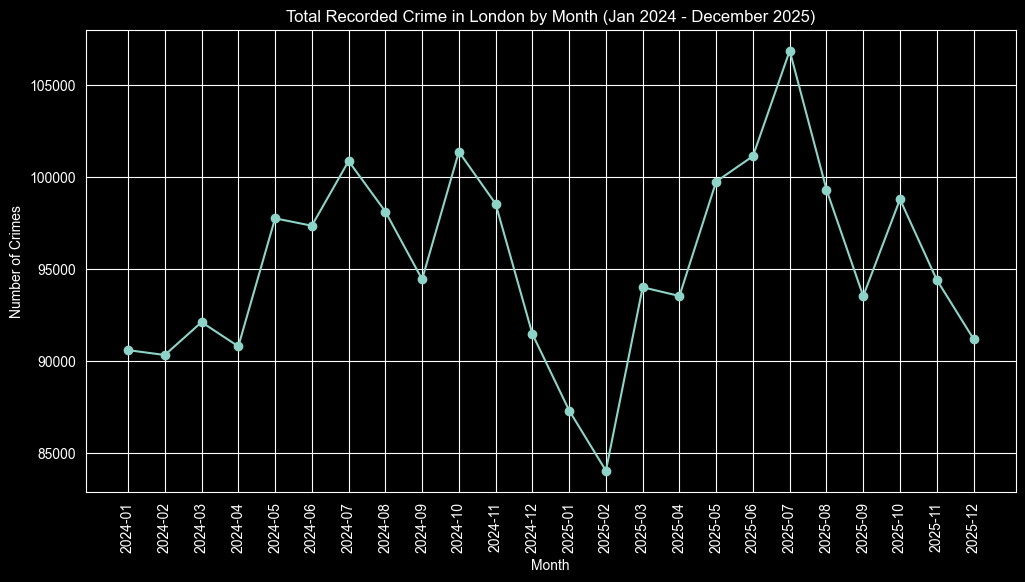

In [33]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(monthly.index, monthly.values, marker="o")

ax.set_title("Total Recorded Crime in London by Month (Jan 2024 - December 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Crimes")
ax.tick_params(axis="x", rotation=90)
;

fig.savefig(figures_dir/"01_crime_over_time.png", bbox_inches="tight")

#### Crime Types

In [21]:
# Types of Crime
crime_type = df["crime_type"].value_counts()
crime_type

crime_type
Violence and sexual offences    522102
Anti-social behaviour           467822
Other theft                     213581
Theft from the person           184999
Vehicle crime                   180677
Shoplifting                     172285
Public order                    113280
Criminal damage and arson       110470
Burglary                        100880
Drugs                            92310
Robbery                          64909
Bicycle theft                    29627
Other crime                      24501
Possession of weapons            10230
Name: count, dtype: int64

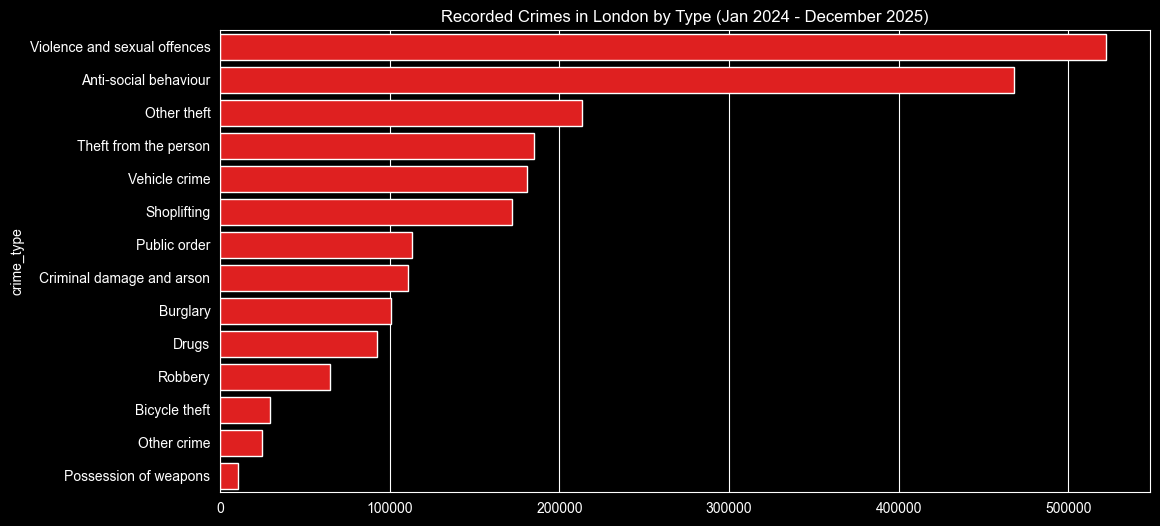

In [32]:
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=crime_type.values, y=crime_type.index, ax=ax, color="red")
ax.set_title("Recorded Crimes in London by Type (Jan 2024 - December 2025)")
;

fig.savefig(figures_dir/"02_crime_type.png", bbox_inches="tight")

#### Crime Types Seasonal Pattern

In [35]:
# Top 6 crimes by volume
top_6 = df["crime_type"].value_counts().head(6).index.tolist()
top_6

['Violence and sexual offences',
 'Anti-social behaviour',
 'Other theft',
 'Theft from the person',
 'Vehicle crime',
 'Shoplifting']

In [58]:
pivot = (
    df[df["crime_type"].isin(top_6)]
    .groupby(["month", "crime_type"])
    .size()
    .unstack("crime_type")
)

pivot

crime_type,Anti-social behaviour,Other theft,Shoplifting,Theft from the person,Vehicle crime,Violence and sexual offences
month,,,,,,
2024-01,16524,10297,5150,6870,8884,21067
2024-02,16976,10584,5392,7869,8067,20522
2024-03,18059,9016,5985,9266,8407,20183
2024-04,18252,8762,6898,8698,8453,19328
2024-05,22170,9027,7015,7429,8410,21770
2024-06,22007,9723,6860,7623,7852,21628
2024-07,22540,9456,8011,7515,7912,22437
2024-08,22213,8760,8130,7178,7802,21072
2024-09,19432,8513,7912,7038,7622,21076


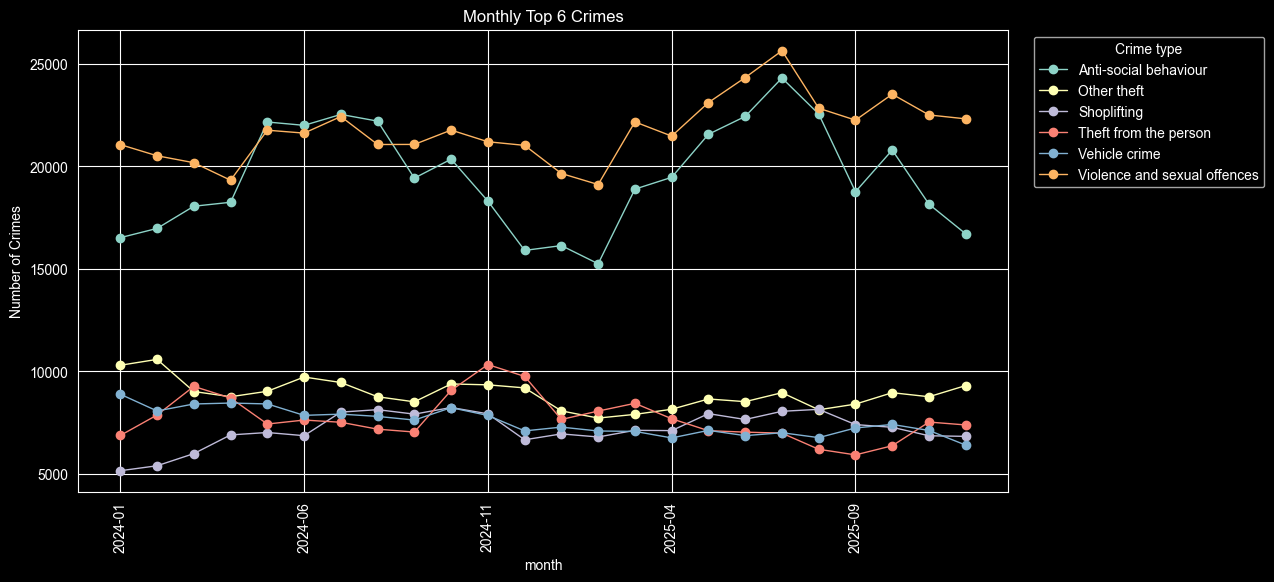

In [50]:
fig, ax = plt.subplots(figsize=(12,6))
pivot.plot(ax=ax, linewidth=1, marker="o")

ax.set_title("Monthly Top 6 Crimes")
ax.set_ylabel("Number of Crimes")
ax.tick_params(axis="x", rotation=90)
ax.legend(title="Crime type", bbox_to_anchor=(1.02, 1), loc="upper left")
;

fig.savefig(figures_dir / "03_seasonality_by_type.png", bbox_inches="tight")

#### Boroughs

In [51]:
# Crimes by Borough
df["borough"] = df["lsoa_name"].str.replace(r"\s+\d+[A-Z]$", "", regex=True)

In [61]:
borough_counts = df["borough"].value_counts().head(20)
borough_counts

borough
Westminster       199661
Camden             99632
Newham             99452
Southwark          96316
Lambeth            94825
Tower Hamlets      93858
Croydon            85971
Brent              85738
Ealing             85197
Islington          80567
Hackney            80166
Hillingdon         77707
Enfield            74010
Lewisham           72403
Barnet             72210
Haringey           71784
Greenwich          67834
Wandsworth         66576
Hounslow           66485
Waltham Forest     61878
Name: count, dtype: int64

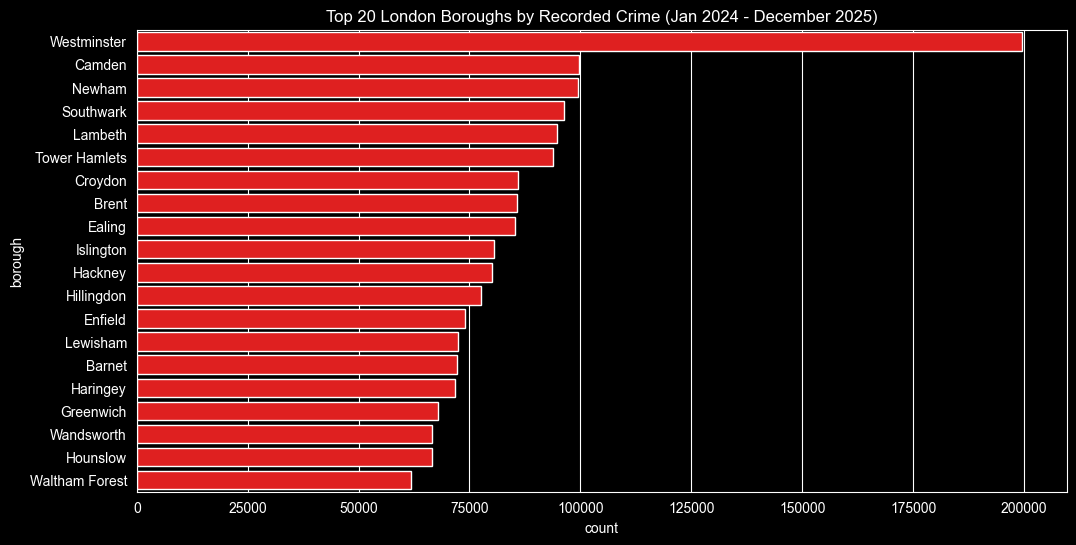

In [65]:
fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(x=borough_counts, y=borough_counts.index, ax=ax, color="red")
ax.set_title("Top 20 London Boroughs by Recorded Crime (Jan 2024 - December 2025)")
;

fig.savefig(figures_dir/"04_crimes_by_borough.png", bbox_inches="tight")

#### Geographical Concentration

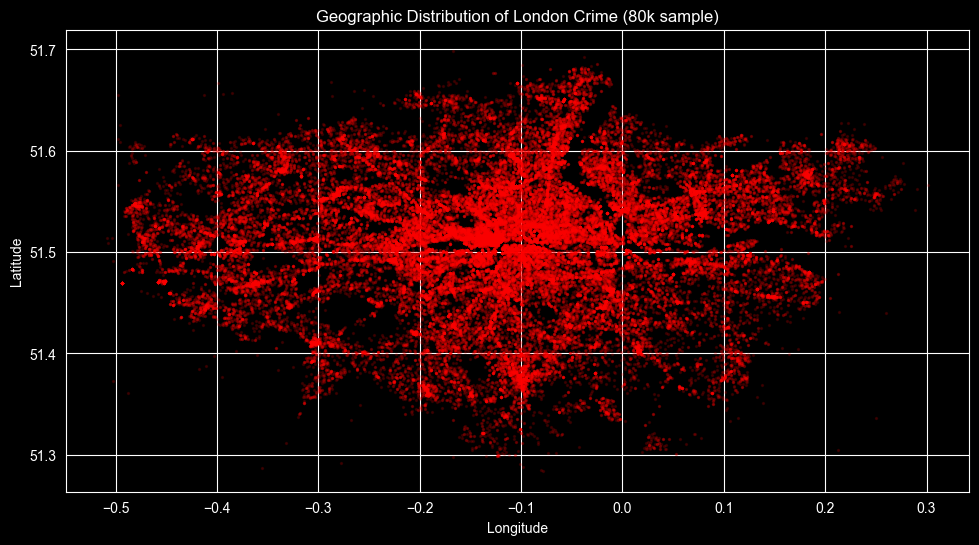

In [70]:
# Sample 80k points
sample = df.sample(n=80_000, random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(sample["longitude"], sample["latitude"],
           s=2, alpha=0.15, color="red")

ax.set_title("Geographic Distribution of London Crime (80k sample)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
;

fig.savefig(figures_dir/"05_geo_dist.png", bbox_inches="tight")

#### Summary



Crime is stable but seasonal. Monthly totals stay around 90,000–100,000, dipping in winter and peaking in summer. February 2025 was the quietest month (84,051) and July 2025 the busiest (106,853). The same pattern repeats across both years.

The crime types are very uneven. Violence and sexual offences (522,102) and anti-social behaviour (467,822) dominate, while possession of weapons (10,230) and other crime (24,501) are tiny by comparison. A large gap exists between the largest and smallest.

Each crime type moves differently through the year. Anti-social behaviour swings hardest, climbing about 60% from its winter low to its summer high. Theft from the person spikes in spring. Vehicle crime stays almost flat all year. Because the types don't move together.

Crime is heavily concentrated in a few places. Westminster alone recorded 199,661 crimes which is almost double the next borough, Camden (99,632).